# 1. Import Library

In [22]:
import pandas as pd

# 2. Load Data

In [23]:
df = pd.read_csv('../datasets/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# 3. Data Understanding

## A. Shape

In [24]:
print('Shape: ',df.shape)

Shape:  (1338, 7)


## B. Columns

In [25]:
print('\n=== Columns: ===')
print(df.columns)


=== Columns: ===
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')


## C. Dtype

In [26]:
print('\nTipe data:')
print(df.dtypes)


Tipe data:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


## D. Info

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


## E. Descriptive Statistics

In [28]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


#### Ringkasan Data Understanding:
1. Shape = 1338 baris dan 7 kolom
2. Tidak ada type data yang salah
3. Tidak ada Missing Value
4. Kolom: age, sex,bmi, children, smoker, region, charges

# 4. Data Preprocessing

## A. Missing Value

In [29]:
print('===== Missing Value ======')
print(df.isnull().sum())


===== Missing Value ======
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


## B. Duplicate

In [30]:
print('Jumlah Data duplicate: ',df.duplicated().sum())
df = df.drop_duplicates()

Jumlah Data duplicate:  1


## C. Encoding

In [31]:
from sklearn.preprocessing import LabelEncoder

le_sex = LabelEncoder()
le_smoker = LabelEncoder()

df['sex'] = le_sex.fit_transform(df['sex'])
df['smoker'] = le_smoker.fit_transform(df['smoker'])
df = pd.get_dummies(df, columns=['region'], dtype=int)
print('=== Encoding Kategori sex ===')
print(df['sex'])
print('\n=== Encoding Kategori smoker ===')
print(df['smoker'])
print('\n=== Encoding Kategori region ===')
display(df)

=== Encoding Kategori sex ===
0       0
1       1
2       1
3       1
4       1
       ..
1333    1
1334    0
1335    0
1336    0
1337    0
Name: sex, Length: 1337, dtype: int64

=== Encoding Kategori smoker ===
0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    0
1335    0
1336    0
1337    1
Name: smoker, Length: 1337, dtype: int64

=== Encoding Kategori region ===


,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,0,1,0,0
1334,18,0,31.920,0,0,2205.98080,1,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,0,1


## D. Validasi Data

In [32]:
print(df[df['age'] <= 0])
df = df[df['age'] > 0]

Empty DataFrame
Columns: [age, sex, bmi, children, smoker, charges, region_northeast, region_northwest, region_southeast, region_southwest]
Index: []


## Ringkasan Data Preprocessing

1. Tidak ditemukan Missing Value
2. Terdapat 1 data duplicate
3. Mengubah kategori sex, smoker, dan region menggunakan encoding
4. Validasi data umur yang tidak valid

# 5. Exploratory Data Analysis (EDA)

## 5.1 Statistik Deskriptif

In [33]:
df.describe()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,0.504862,30.663452,1.095737,0.204936,13279.121487,0.242334,0.242334,0.272251,0.243082
std,14.044333,0.500163,6.100468,1.205571,0.403806,12110.359656,0.428655,0.428655,0.445285,0.429104
min,18.000000,0.000000,15.960000,0.000000,0.000000,1121.873900,0.000000,0.000000,0.000000,0.000000
25%,27.000000,0.000000,26.290000,0.000000,0.000000,4746.344000,0.000000,0.000000,0.000000,0.000000
50%,39.000000,1.000000,30.400000,1.000000,0.000000,9386.161300,0.000000,0.000000,0.000000,0.000000
75%,51.000000,1.000000,34.700000,2.000000,0.000000,16657.717450,0.000000,0.000000,1.000000,0.000000
max,64.000000,1.000000,53.130000,5.000000,1.000000,63770.428010,1.000000,1.000000,1.000000,1.000000


### Insight:

- Rentang Usia peserta 18 hingga 64 tahun, dengan rata rata usia 34 tahun
- Rata-rata BMI sebesar 30.66
- Sebagian besar peserta memiliki 1 anak, dengan jumlah anak berkisar antara 0 sampai 5
- Biaya medis memiliki rentang yang cukup besar, dari 1.122 hingga 63.770, menunjukkan variasi biaya medis yang tinggi.

## 5.2 Histogram

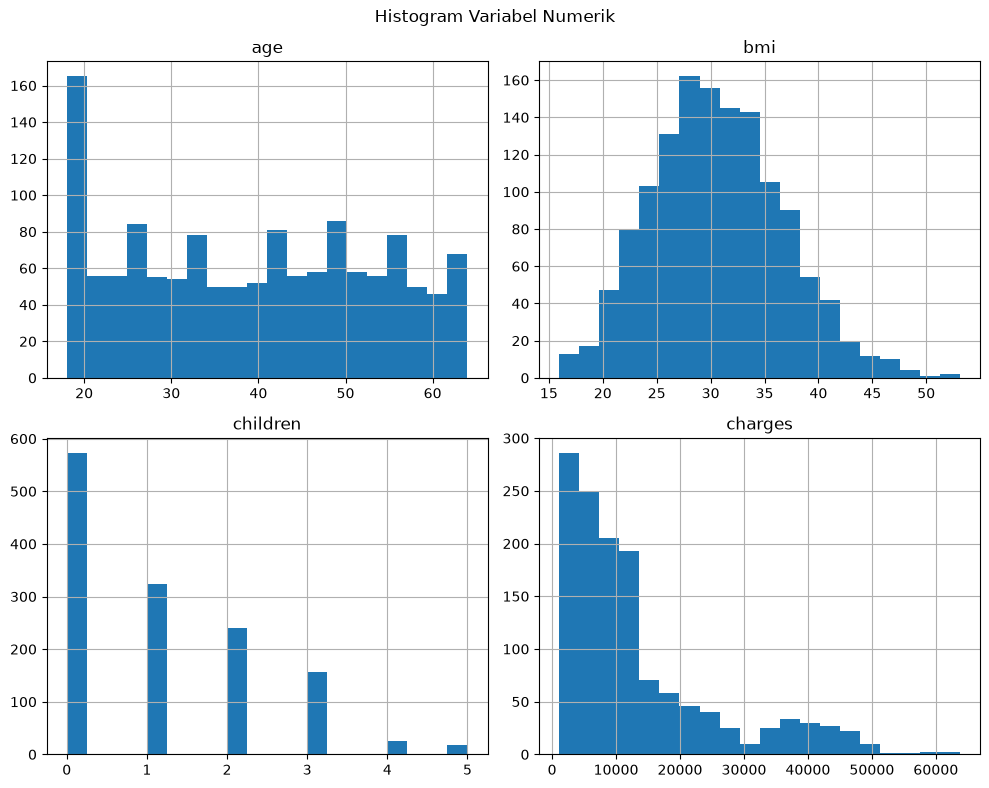

In [34]:
import matplotlib.pyplot as plt

numeric_columns = ['age', 'bmi', 'children', 'charges']
df[numeric_columns].hist(figsize=(10, 8), bins=20)

plt.suptitle("Histogram Variabel Numerik")
plt.tight_layout()
plt.show()

### Insight:

Histogram age:
Distribusi usia peserta relatif merata dan tidak menunjukkan kemiringan (skew) yang signifikan.

Histogram bmi:
Distribusi BMI mendekati simetris, dengan sebagian besar peserta memiliki BMI di sekitar nilai tengah

Histogram children:
Grafik tersebut menunjukkan distribusi data yang cenderung skew kanan.Artinya jumlah orang yang memiliki anak sedikit cenderung banyak dibandingkan dengan jumlah anak yang banyak.

Charges:
Distribusi biaya medis (charge) cenderung skew kanan, yang menunjukkan sebagian besar peseerta memiliki biaya medis yang relatif rendah hingga sedang,sementara sebagian kecil peserta memiliki biaya sangat tinggi. 

## 5.3 Boxplot

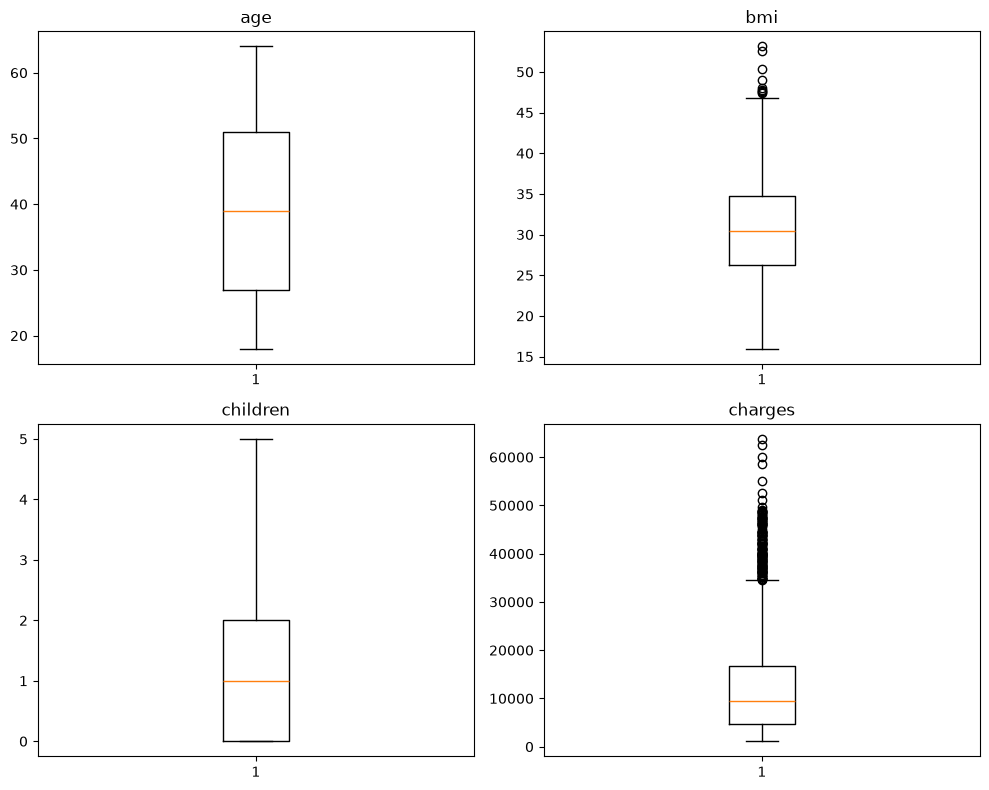

In [35]:
numerical_columns = ['age', 'bmi', 'children', 'charges']

plt.figure(figsize=(10, 8))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(2, 2, i)
    plt.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### insight Boxplot

1. Boxplot usia tidak memiliki outlier. Hal ini menunjukkan bahwa rentang usia peseerta masih berada pada batas yang wajar.
2. Boxplot BMI memiliki beberapa outlier, yang mengindikasikan terdapat beberapa peserta dengan BMI jauh lebih tinggi dibandingkan mayoritas peserta.
3. Boxplot jumlah anak cenderung tidak terdapat outlier.Sebagian besar peserta memiliki 0 sampai 2 anak.
4. Boxplot charges memiliki beberapa outlier bernilai tinggi. Hal ini mengindikasikan terdapat sebagian kecil peserta dengan biaya medis lebih tinggi dibandingkan mayoritas peserta.

## 5.4 Heatmap

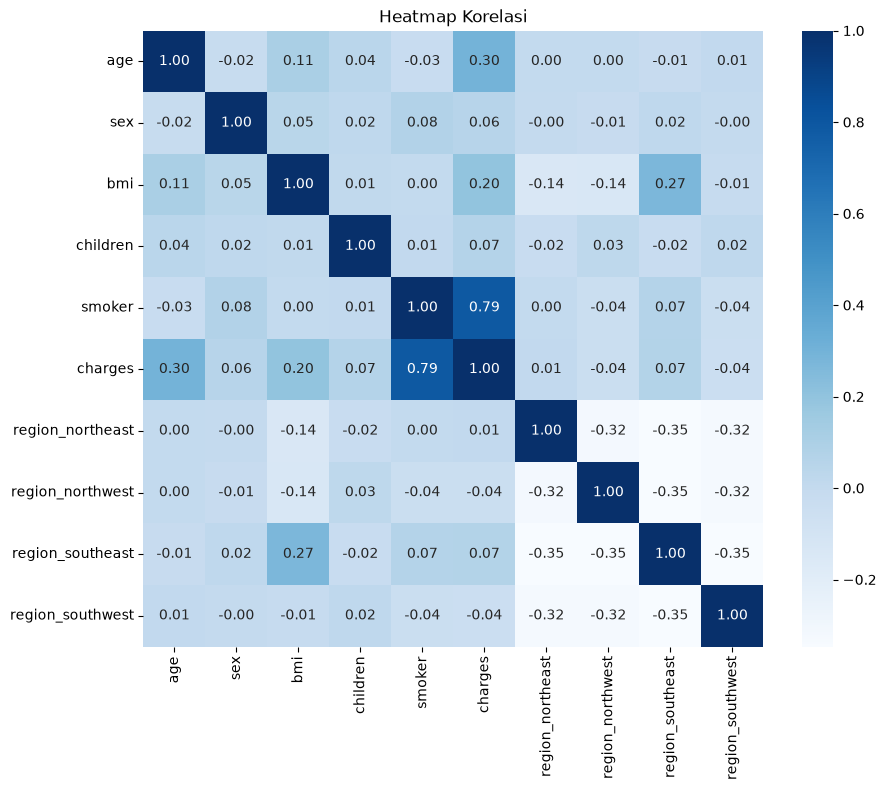

In [36]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Heatmap Korelasi')
plt.show()

### Insight Heatmap
1. Variabel smoker memiliki korelasi positif yang cukup kuat dengan charges. Hal ini menunjukkan bahwa peserta yang merokok cenderung memiliki biaya medis cukup tinggi.

2. Variabel age memiliki korelasi positif terhadap charges, sehingga semakin bertambah usia, biaya medis cenderung meningkat.

3. BMI memiliki korelasi positif terhadap biaya medis, sehingga peserta dengan BMI tinggi cenderung memiliki biaya medis yang lebih besar.

# 6. Feature & Target

In [37]:
X = df.drop('charges', axis=1)
y = df['charges']

print('Feature:')
display(X.head())

print('\nTarget:')
display(y.head())

Feature:


,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,0,0,0,1
1,18,1,33.770,1,0,0,0,1,0
2,28,1,33.000,3,0,0,0,1,0
3,33,1,22.705,0,0,0,1,0,0
4,32,1,28.880,0,0,0,1,0,0



Target:


0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

## 6.1 Penjelasan Feature & Target

1. Feature yang digunakan adalah age, sex, bmi, children, smoker, region_northeast, region_northwest, region_southeast, region_southwest untuk memprediksi target biaya medis.

2. Target yang digunakan adalah charges, Karena tujuan utama dari project ini adalah membangun model Linear Regression untuk memprediksi biaya medis berdasarkan karakteristik peserta.

# 7. Train-Test-Split

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Jumlah data training: ', X_train.shape)
print('Jumlah data testing: ', X_test.shape)

Jumlah data training:  (1069, 9)
Jumlah data testing:  (268, 9)


## Penjelasan Train-Test-Split

Datasets dibagi menjadi data training (80%) dan data testing (20%).Data training digunakan untuk melatih model Linear Regression, sedangkan data testing digunakan untuk menguji data yang belum pernah dilihat.Parameter random_state=42 digunakan agar proses pembagian data bersifat konsisten setiap kali program dijalankan.

# 8. Feature Scaling

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Data Training:')
print(X_train[:5])
print('\nData Testing:')
print(X_test[:5])

Data Training:
[[-1.1576804   0.97140947 -0.99692768 -0.90790804 -0.50029231  1.79591103
  -0.57266946 -0.60581158 -0.57410974]
 [-1.30061876  0.97140947 -0.79276204  0.7669042  -0.50029231  1.79591103
  -0.57266946 -0.60581158 -0.57410974]
 [ 0.91492586 -1.029432    1.15466402  0.7669042  -0.50029231 -0.55682046
   1.74620801 -0.60581158 -0.57410974]
 [ 1.70108686  0.97140947  1.80683684 -0.90790804 -0.50029231 -0.55682046
  -0.57266946  1.65067825 -0.57410974]
 [ 0.55757996 -1.029432   -0.6514166   0.7669042  -0.50029231  1.79591103
  -0.57266946 -0.60581158 -0.57410974]]

Data Testing:
[[ 0.70051832  0.97140947 -1.3267337  -0.90790804 -0.50029231  1.79591103
  -0.57266946 -0.60581158 -0.57410974]
 [-0.72886531 -1.029432   -0.8167329   2.44171645 -0.50029231 -0.55682046
  -0.57266946 -0.60581158  1.74182728]
 [ 0.84345668 -1.029432    0.96620343  1.60431032 -0.50029231 -0.55682046
   1.74620801 -0.60581158 -0.57410974]
 [-0.58592695  0.97140947  0.63639741  1.60431032  1.99883143 -0.

## Penjelasan Feature Scaling

1. Mengapa Feature Scaling dilakukan?
2. Mengapa X_train menggunakan fit_transform(), sedangkan X_test hanya menggunakan transform()?

1. Feature Scaling dilakukan agar semua feature memiliki skala yang sebanding, shingga tidak ada feature dengan rentang nilai yang sangat jauh lebih besar dibanding feature lainnya. Hal ini membantu proses pelatihan model menjadi lebih konsisten.

2. X_train menggunakan fit_transform() karena scaler perlu menghitung mean dan standar deviasi dari data training terlebih dahulu, kemudian melakukan scaling. Sementara itu, X_test hanya menggunakan transform() agar proses scaling menggunakan parameter yang sama dari data training dan menghindari terjadinya data leakage.

# 9. Membangun Model Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

## Penjelasan

Model Linear Regression dibuat menggunakan data training. Pada tahap ini, model mempelajari hubungan antara seluruh feature dengan target(charges) untuk membentuk persamaan regresi yang dapat digunakan dalam proses prediksi.

# 10. Prediksi

In [41]:
y_pred = model.predict(X_test)
hasil = pd.DataFrame({
    'Actual': y_test,
    'Prediction': y_pred
})

hasil.head(10)

,Actual,Prediction
900,8688.85885,8143.693884
1064,5708.86700,5737.115683
1256,11436.73815,14369.314876
298,38746.35510,31745.513636
237,4463.20510,8962.386657
481,9304.70190,13149.722353
240,38511.62830,30446.760679
277,2150.46900,1453.288813
415,7345.72660,10633.018402
707,10264.44210,11318.943794


# 11. Evaluasi Model

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('MAE: ', mae)
print('MSE: ', mse)
print('RMSE: ', rmse)
print('R2 Score: ', r2)

MAE:  4177.045561036324
MSE:  35478020.675235584
RMSE:  5956.342894363586
R2 Score:  0.8069287081198013


### Penjelasan Evaluasi

- Mean Absolut Error (MAE) sebesar 4177.05 menunjukkan bahwa rata rata selisih antara nilai prediksi dengan nilai sebenarnya adalah 4177 satuan biaya medis.

- Mean Square Error (MSE) sebesar 35.478.020,68 menunjukkan rata rata kuadrat dari error prediksi.Nilai ini digunakan untuk memberikan penalti lebih besar terhadap prediksi yang memiliki kesalahan yang tinggi.

- Root Mean Square Error (RMSE) sebesar 5956.34 menunjukkan bahwa rata rata kesalahan prediksi model adalah sekitar 5956.34 dalam satuan biaya medis.

- R2 Score sebesar 0.8069 menunjukkan bahwa model Linear Regression mampu menjelaskan sekitar 80.69% variasi biaya medis berdsarkan feature yang digunakan.Nilai ini menunjukkan bahwa model memiliki performa yng cukup baik.

# 12. Kesimpulan

Pada mini project ini telah berhasil dibangun model Linear Regression untuk memprediksi biaya medis dengan berdsarkan beberapa feature, yaitu age, sex, bmi, children, smoker, dan region.

Sebelum membangun model, dilakukan Data Preprocessing dan Exploratory Data Analysis (EDA) untuk memahami karakteristik data serta mempersiapkan data agar siap digunakan.Hasil EDA menunjukkan bahwa variabel smoker memiliki hubungan paling kuat dengan biaya medis, diikuti oleh age dan bmi.

Berdasarkan hasil evaluasi, model memperoleh R2 Score sebesar 0.8069, yang berarti model mampu menjelaskan sekitar 80.69% variasi biaya medis.Nilai tersebut menunjukkan bahwa model memiliki performa yang baik dalam melakukan prediksi pada dataset ini.